**Implementation of Convolutional Neural Network using Keras.**

**Task 1: Data Understanding and Visualization**

In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/AI and ML/Copy of FruitinAmazon.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed!")

Extraction completed!


In [ ]:
base_path = "/content/dataset/FruitinAmazon"

train_dir = os.path.join(base_path, "train")
test_dir  = os.path.join(base_path, "test")

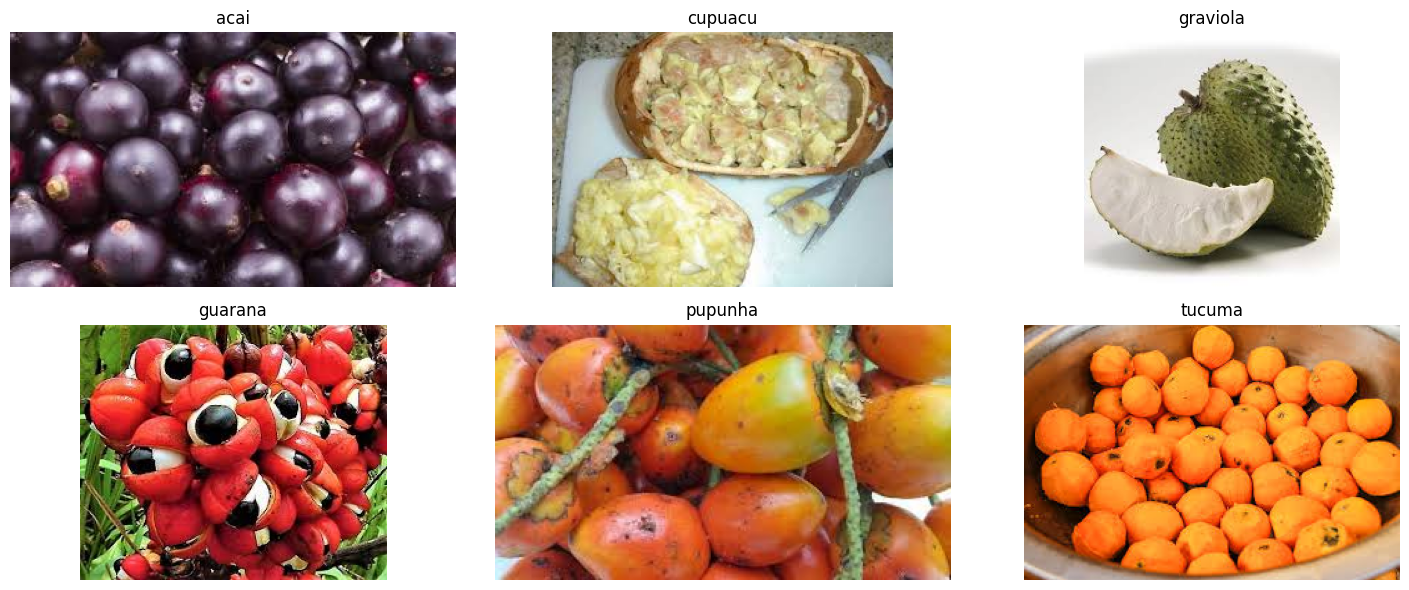

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# Get class folders from train
class_names = sorted(os.listdir(train_dir))

selected_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    if not os.path.isdir(class_path):
        continue

    images = os.listdir(class_path)
    if len(images) == 0:
        continue

    random_image = random.choice(images)
    image_path = os.path.join(class_path, random_image)

    selected_images.append((class_name, image_path))

# Plot in 2 rows
num_classes = len(selected_images)
cols = (num_classes + 1) // 2

plt.figure(figsize=(15, 6))

for i, (class_name, img_path) in enumerate(selected_images):
    img = Image.open(img_path)

    plt.subplot(2, cols, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

Six different fruits were observed, and the images show variations in lighting, background, and orientation, indicating a diverse and well-labeled dataset suitable for classification.

In [ ]:
import os
from PIL import Image

corrupted_images = []

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    if not os.path.isdir(class_path):
        continue

    for image_name in os.listdir(class_path):
        image_path = os.path.join(class_path, image_name)

        try:
            img = Image.open(image_path)
            img.verify()  # check if image is valid

        except (IOError, SyntaxError):
            corrupted_images.append(image_path)
            os.remove(image_path)
            print(f"Removed corrupted image: {image_path}")

# Final report
if len(corrupted_images) == 0:
    print("No Corrupted Images Found.")
else:
    print(f"Total corrupted images removed: {len(corrupted_images)}")

No Corrupted Images Found.


**Task 2: Loading and Preprocessing Image Data in keras**

In [ ]:
import tensorflow as tf

# Image and training parameters
img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

# Rescaling layer (normalize pixel values)
rescale = tf.keras.layers.Rescaling(1./255)

# Training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

# Apply normalization
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.


In [ ]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

# Apply normalization
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 18 files for validation.


**Task 3 - Implement a CNN**

In [ ]:
train_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

class_names = train_ds_raw.class_names
num_classes = len(class_names)

rescale = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds_raw.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.


In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

# CNN Model
model = keras.Sequential([

    # Input Layer
    layers.Input(shape=(img_height, img_width, 3)),

    # Conv Layer 1
    layers.Conv2D(32, (3, 3), padding='same', strides=1),
    layers.ReLU(),

    # Pooling 1
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    # Conv Layer 2
    layers.Conv2D(32, (3, 3), padding='same', strides=1),
    layers.ReLU(),

    # Pooling 2
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    # Flatten
    layers.Flatten(),

    # Fully Connected Layers
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),

    # Output Layer
    layers.Dense(num_classes, activation='softmax')
])

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
epochs = 20

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 856ms/step - accuracy: 0.1250 - loss: 2.1399 - val_accuracy: 0.8333 - val_loss: 1.2068
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 427ms/step - accuracy: 0.1667 - loss: 1.8002 - val_accuracy: 0.0556 - val_loss: 1.6173
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 425ms/step - accuracy: 0.2500 - loss: 1.6269 - val_accuracy: 0.0556 - val_loss: 1.7713
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 424ms/step - accuracy: 0.4861 - loss: 1.4620 - val_accuracy: 0.5556 - val_loss: 1.4639
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 421ms/step - accuracy: 0.7361 - loss: 1.2070 - val_accuracy: 0.8333 - val_loss: 0.7709
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 464ms/step - accuracy: 0.5972 - loss: 1.0614 - val_accuracy: 0.6111 - val_loss: 1.1370
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 527ms/step - accuracy: 0.8194 - loss: 0.7893 - val_accuracy: 0.6111 - val_loss: 1.0550
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 749ms/step - accuracy: 0.8611 - loss: 0.5975 - val_accuracy: 0.8333 - val_loss:

**Task 4: Compile the Model**

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow import keras

# Callbacks
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="best_model.keras",
        monitor="val_loss",
        save_best_only=True
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )
]

# Training
history = model.fit(
    train_ds,
    validation_data=val_ds,
    batch_size=16,
    epochs=250,
    callbacks=callbacks
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 585ms/step - accuracy: 0.9167 - loss: 0.3378 - val_accuracy: 0.7222 - val_loss: 1.2123
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 438ms/step - accuracy: 0.8472 - loss: 0.4287 - val_accuracy: 0.7222 - val_loss: 1.8023
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 494ms/step - accuracy: 0.9306 - loss: 0.1847 - val_accuracy: 0.7778 - val_loss: 0.6396
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 875ms/step - accuracy: 0.9861 - loss: 0.0968 - val_accuracy: 0.9444 - val_loss: 0.1138
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 819ms/step - accuracy: 0.9306 - loss: 0.2067 - val_accuracy: 1.0000 - val_loss: 0.0717
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 422ms/step - accuracy: 0.9861 - loss: 0.0987 - val_accuracy: 0.8889 - val_loss: 0.1845
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 426ms/step - accuracy: 1.0000 - loss: 0.0234 - val_accuracy: 0.8889 - val_loss: 0.3656
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 423ms/step - accuracy: 1.0000 - loss: 0.0215 - val_accuracy: 0.8333 - v

**Task 5: Evaluate the Model**

In [ ]:
 # Create test dataset (no validation split, no shuffle)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

# Apply same normalization
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

# Evaluate model
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Found 30 files belonging to 6 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.6333 - loss: 0.8847
Test Loss: 0.8846709132194519
Test Accuracy: 0.6333333253860474


**Task 6: Save and Load the Model**

In [ ]:
import tensorflow as tf
from tensorflow import keras

# Save the trained model
model.save("cnn_model.h5")

# Load the saved model
loaded_model = keras.models.load_model("cnn_model.h5")

# Evaluate on test dataset
test_loss, test_accuracy = loaded_model.evaluate(test_ds)

print("Loaded Model Test Loss:", test_loss)
print("Loaded Model Test Accuracy:", test_accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 508ms/step - accuracy: 0.6333 - loss: 0.8847
Loaded Model Test Loss: 0.8846709132194519
Loaded Model Test Accuracy: 0.6333333253860474


**Task 7: Predictions and Classification Report**

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

# Get true labels and predictions
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

# Convert to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Classification Report
print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step
              precision    recall  f1-score   support

        acai       1.00      0.60      0.75         5
     cupuacu       0.44      0.80      0.57         5
    graviola       0.80      0.80      0.80         5
     guarana       0.80      0.80      0.80         5
     pupunha       0.50      0.20      0.29         5
      tucuma       0.50      0.60      0.55         5

    accuracy                           0.63        30
   macro avg       0.67      0.63      0.63        30
weighted avg       0.67      0.63      0.63        30



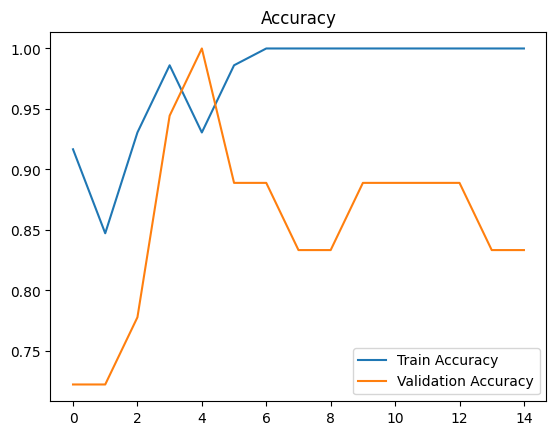

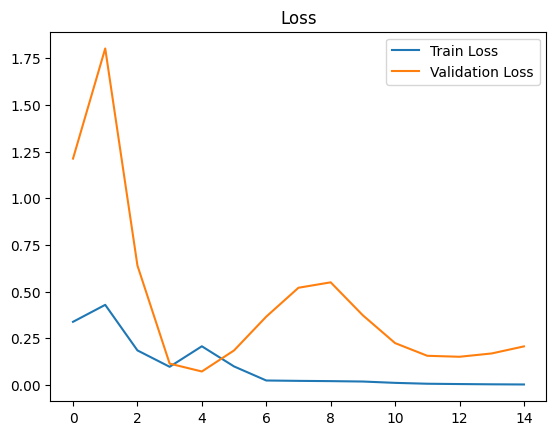

In [ ]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss plot
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss")
plt.show()